In [1]:
import pandas as pd
import numpy as np
import itertools as it
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
%matplotlib inline
sns.set_theme(style="darkgrid")

In [3]:
rep="/Users/gilles/sDrive/Recherche/BoSchal/WordStructure/Data/vlexique2/"

In [4]:
dfVlexique=pd.read_csv(rep+"vlexique_paradigms.csv")

In [5]:
dfVlexique.drop("frequency_per_million",axis=1,inplace=True)
dfVlexique.loc[:,"phon_form"]=dfVlexique.loc[:,"phon_form"].apply(lambda x: x.replace(" ",""))
dfVlexique.orth_form=dfVlexique.orth_form.astype(str)
dfVlexique.head()

,form_id,lexeme,cell,phon_form,orth_form,overabundance_tag,frequency
0,form-abaisser-cond-1pl,abaisser,cond.prs.1.pl,abɛsəʁjɔ̃,abaisserions,NaN,0
1,form-abaisser-cond-1sg,abaisser,cond.prs.1.sg,abɛsəʁE,abaisserais,NaN,38
2,form-abaisser-cond-2pl,abaisser,cond.prs.2.pl,abɛsəʁje,abaisseriez,NaN,9
3,form-abaisser-cond-2sg,abaisser,cond.prs.2.sg,abɛsəʁE,abaisserais,NaN,14
4,form-abaisser-cond-3pl,abaisser,cond.prs.3.pl,abɛsəʁE,abaisseraient,NaN,4


In [6]:
maxFreq=dfVlexique.frequency.max()

### Correspondances entre Flexique et Grace

In [7]:
cells=dfVlexique.cell.unique().tolist()
caseGrace={}
caseFlex={}
for cell in cells:
    lFeat=cell.split(".")
    nFeat=len(lFeat)
    if nFeat==1:
        caseGrace[cell]=cell
    elif nFeat==2:
        caseGrace[cell]="pP"
    elif lFeat[1]=="prs":
        if lFeat[0]=="imp":
            caseGrace[cell]="pI"+lFeat[2]+lFeat[3][0].upper()
        else:
            caseGrace[cell]="p"+lFeat[0][0]+lFeat[2]+lFeat[3][0].upper()
    elif lFeat[1]=="pst":
        if lFeat[0]=="ind":
            caseGrace[cell]="ai"+lFeat[2]+lFeat[3][0].upper()
        elif lFeat[0]=="sbjv":
            caseGrace[cell]="is"+lFeat[2]+lFeat[3][0].upper()
        else:
            caseGrace[cell]="pp"+lFeat[2].upper()+lFeat[3][0].upper()
    else:
        caseGrace[cell]=lFeat[1][0]+lFeat[0][0]+lFeat[2]+lFeat[3][0].upper()
for case in caseGrace:
    caseFlex[caseGrace[case]]=case

In [8]:
caseGrace

{'cond.prs.1.pl': 'pc1P',
 'cond.prs.1.sg': 'pc1S',
 'cond.prs.2.pl': 'pc2P',
 'cond.prs.2.sg': 'pc2S',
 'cond.prs.3.pl': 'pc3P',
 'cond.prs.3.sg': 'pc3S',
 'ind.fut.1.pl': 'fi1P',
 'ind.fut.1.sg': 'fi1S',
 'ind.fut.2.pl': 'fi2P',
 'ind.fut.2.sg': 'fi2S',
 'ind.fut.3.pl': 'fi3P',
 'ind.fut.3.sg': 'fi3S',
 'imp.prs.1.pl': 'pI1P',
 'imp.prs.2.pl': 'pI2P',
 'imp.prs.2.sg': 'pI2S',
 'inf': 'inf',
 'ind.ipfv.1.pl': 'ii1P',
 'ind.ipfv.1.sg': 'ii1S',
 'ind.ipfv.2.pl': 'ii2P',
 'ind.ipfv.2.sg': 'ii2S',
 'ind.ipfv.3.pl': 'ii3P',
 'ind.ipfv.3.sg': 'ii3S',
 'ind.prs.1.pl': 'pi1P',
 'ind.prs.1.sg': 'pi1S',
 'ind.prs.2.pl': 'pi2P',
 'ind.prs.2.sg': 'pi2S',
 'ind.prs.3.pl': 'pi3P',
 'ind.prs.3.sg': 'pi3S',
 'ptcp.prs': 'pP',
 'ind.pst.1.pl': 'ai1P',
 'ind.pst.1.sg': 'ai1S',
 'ind.pst.2.pl': 'ai2P',
 'ind.pst.2.sg': 'ai2S',
 'ind.pst.3.pl': 'ai3P',
 'ind.pst.3.sg': 'ai3S',
 'ptcp.pst.f.pl': 'ppFP',
 'ptcp.pst.f.sg': 'ppFS',
 'ptcp.pst.m.pl': 'ppMP',
 'ptcp.pst.m.sg': 'ppMS',
 'sbjv.pst.1.pl': 'is1P',

In [9]:
%store -r pltCellColors
pltFlexColors={}
for case in pltCellColors:
    pltFlexColors[caseFlex[case]]=pltCellColors[case]

In [10]:
dfVlexique=dfVlexique.groupby(["lexeme","cell","phon_form"])[["orth_form","frequency"]].agg({"orth_form":', '.join,"frequency":"sum"}).reset_index()

In [11]:
dfVlexique[dfVlexique.orth_form.str.contains(",")]

,lexeme,cell,phon_form,orth_form,frequency
1072,abréger,cond.prs.1.pl,abʁɛʒəʁjɔ̃,"abrègerions, abrégerions",0
1073,abréger,cond.prs.1.sg,abʁɛʒəʁE,"abrègerais, abrégerais",2
1074,abréger,cond.prs.2.pl,abʁɛʒəʁje,"abrègeriez, abrégeriez",0
1075,abréger,cond.prs.2.sg,abʁɛʒəʁE,"abrègerais, abrégerais",0
1076,abréger,cond.prs.3.pl,abʁɛʒəʁE,"abrègeraient, abrégeraient",1
...,...,...,...,...,...
269451,éviscérer,ind.fut.1.sg,EvisɛʁəʁE,"éviscèrerai, éviscérerai",3
269452,éviscérer,ind.fut.2.pl,Evisɛʁəʁe,"éviscèrerez, éviscérerez",0
269453,éviscérer,ind.fut.2.sg,Evisɛʁəʁa,"éviscèreras, éviscéreras",1
269454,éviscérer,ind.fut.3.pl,Evisɛʁəʁɔ̃,"éviscèreront, éviscéreront",0


In [12]:
def ExtractSubLex(df,low,high=maxFreq):
    return df[(low<df.frequency)&(df.frequency<=high)].sort_values("frequency")

In [13]:
def MakeParadigm(df):
    return pd.pivot_table(df, values='phon_form', index=['lexeme'], columns=['cell'], aggfunc=lambda x: ",".join(x))

In [14]:
dfLex=ExtractSubLex(dfVlexique,0)
len(dfLex)

109215

<Axes: xlabel='cell'>

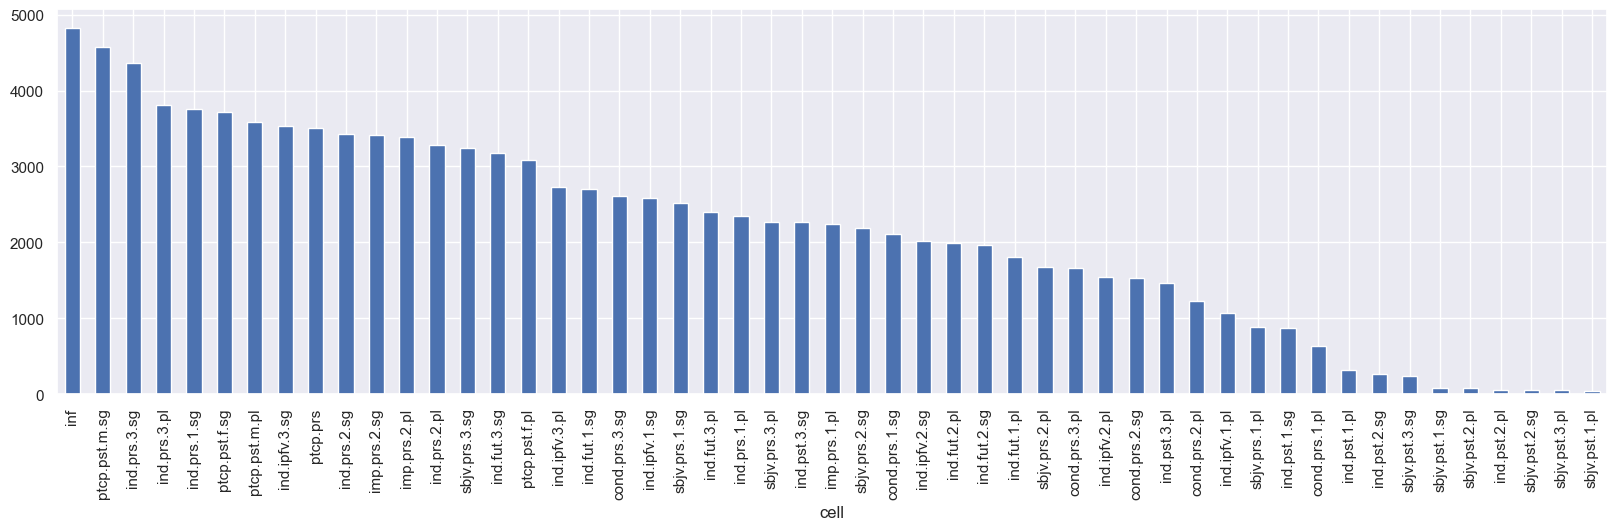

In [15]:
dfLex.groupby(["cell"])["frequency"].count().sort_values(ascending=False).plot(kind="bar",figsize=(20,5))

<Axes: xlabel='cell'>

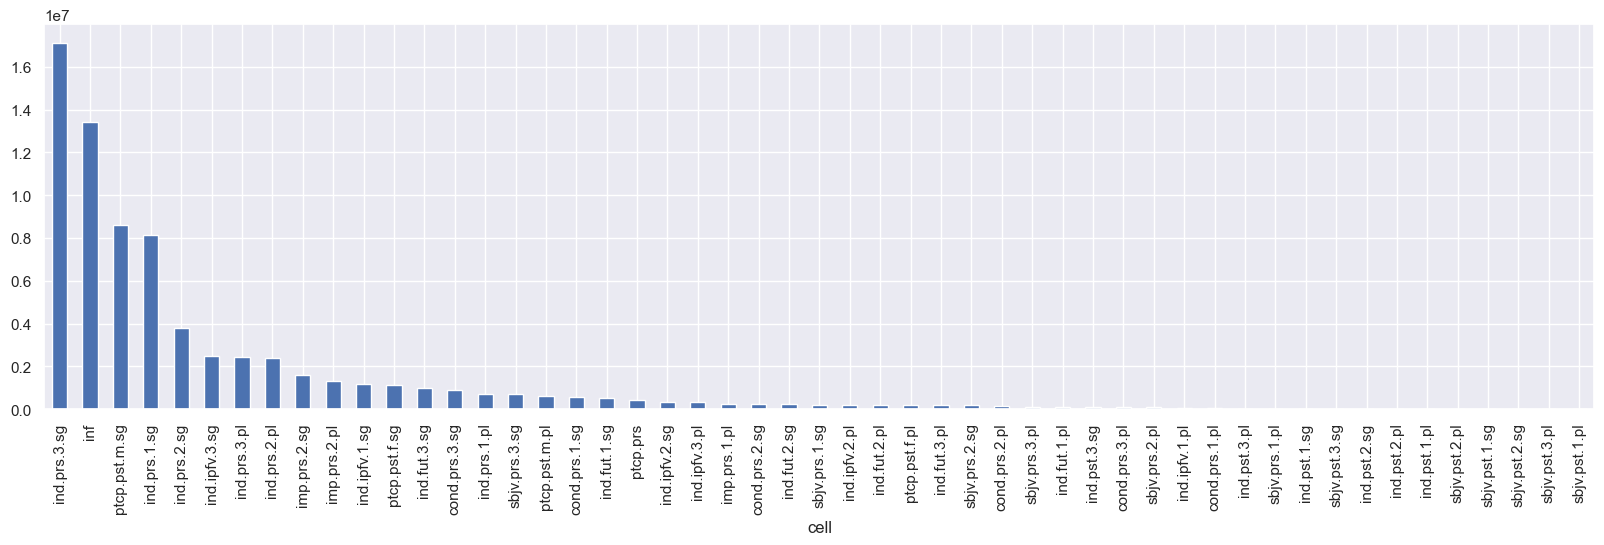

In [16]:
dfLex.groupby(["cell"])["frequency"].sum().sort_values(ascending=False).plot(kind="bar",figsize=(20,5),logy=False)

In [17]:
dfSample={}
dfGold={}
dfFreq={}
nForms=len(dfLex)
for i in range(10):
    numForm=round(nForms*(i)/10)
    dfFreq[i]=dfLex.iloc[[numForm]]["frequency"].values[0]
    print ("%d%%"%((10-i)*10), numForm,dfFreq[i])
    dfSample[i]=ExtractSubLex(dfVlexique,dfFreq[i]-1)
    dfGold[i]=ExtractSubLex(dfVlexique,0,dfFreq[i])
    print (len(dfSample[i]))

100% 0 1
109215
90% 10922 1
109215
80% 21843 2
88572
70% 32764 3
77870
60% 43686 5
65823
50% 54608 8
55925
40% 65529 15
44172
30% 76450 30
33241
20% 87372 74
21898
10% 98294 263
10955


In [18]:
numSample=0
numQ=5
dfSample[numSample]["quartile"]=pd.qcut(dfSample[numSample]["frequency"],numQ)

<Axes: xlabel='quartile'>

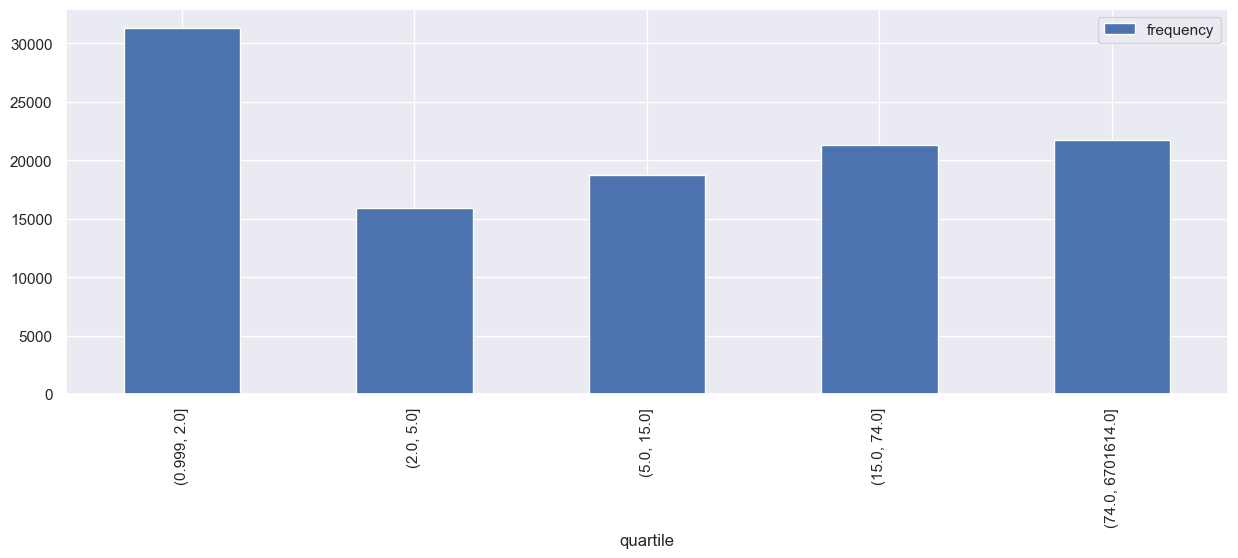

In [19]:
dfSample[numSample].groupby(["quartile"],observed=True)[["frequency"]].count().plot(kind="bar",figsize=(15,5),logy=False)

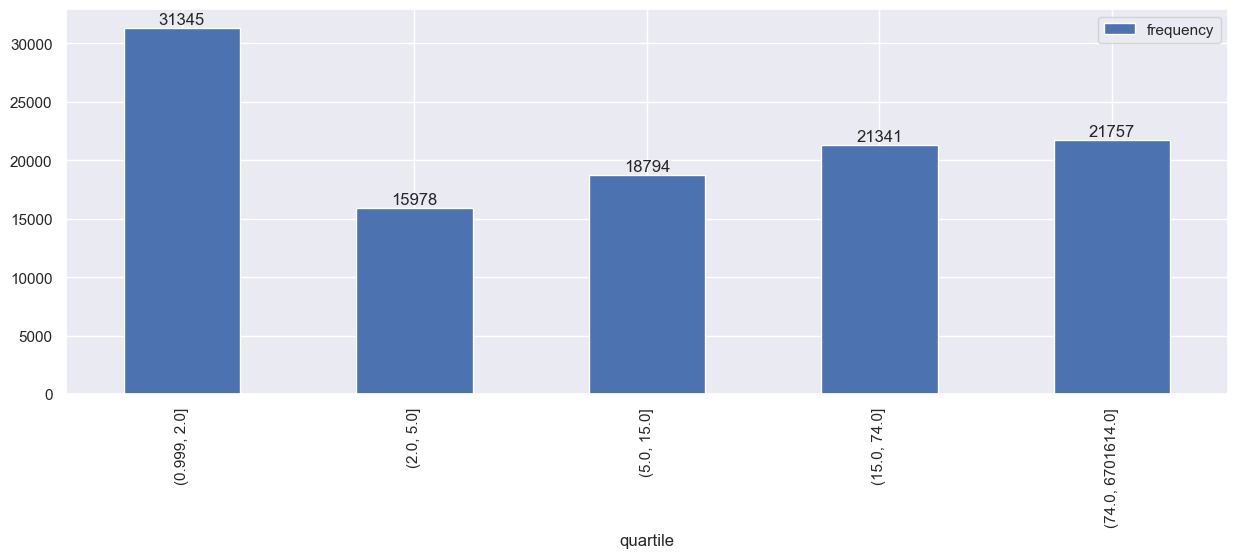

In [20]:
ax=dfSample[numSample].groupby(["quartile"],observed=True)[["frequency"]].count().plot.bar(figsize=(15,5),logy=False)
for container in ax.containers:
    ax.bar_label(container)

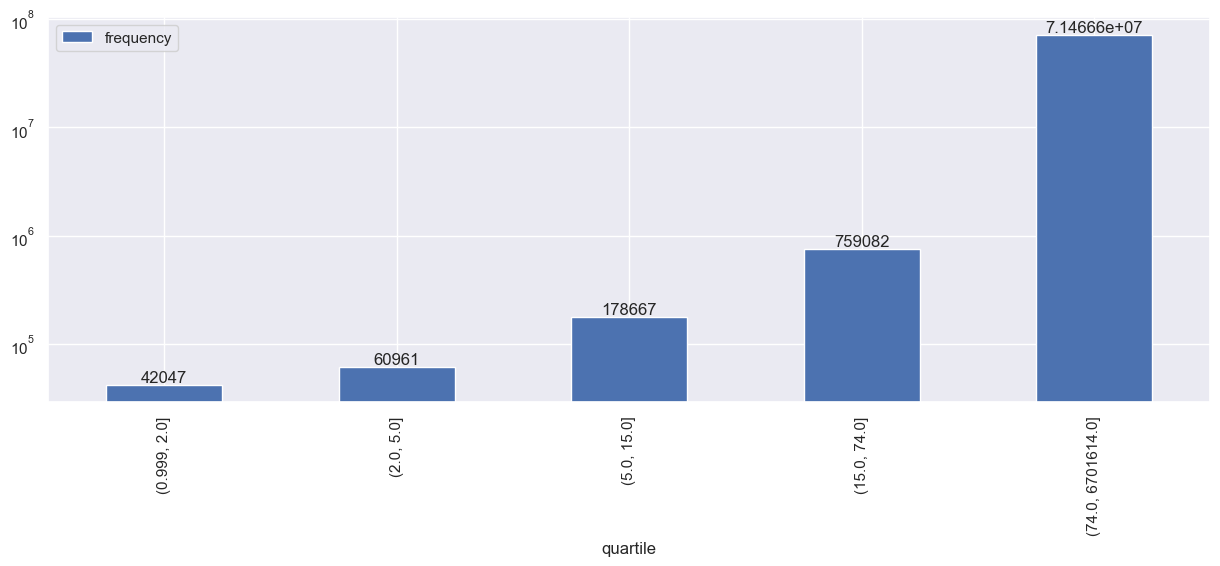

In [21]:
ax=dfSample[numSample].groupby(["quartile"],observed=True)[["frequency"]].sum().plot.bar(figsize=(15,5),logy=True)
for container in ax.containers:
    ax.bar_label(container)

In [22]:
dfSample[numSample].groupby(["quartile"],observed=True)[["frequency"]].count()

,frequency
quartile,
"(0.999, 2.0]",31345
"(2.0, 5.0]",15978
"(5.0, 15.0]",18794
"(15.0, 74.0]",21341
"(74.0, 6701614.0]",21757


In [23]:
def pivotLexique(lexique):
    paradigmes=pd.pivot_table(lexique, values='phon_form', index=['lexeme'], columns=['cell'], aggfunc=lambda x: ",".join(x))
    return paradigmes

In [24]:
dfParLex=pivotLexique(dfSample[9])
dfParLex.head()

cell,cond.prs.1.pl,cond.prs.1.sg,cond.prs.2.pl,cond.prs.2.sg,cond.prs.3.pl,cond.prs.3.sg,imp.prs.1.pl,imp.prs.2.pl,imp.prs.2.sg,ind.fut.1.pl,...,ptcp.pst.f.sg,ptcp.pst.m.pl,ptcp.pst.m.sg,sbjv.prs.1.pl,sbjv.prs.1.sg,sbjv.prs.2.pl,sbjv.prs.2.sg,sbjv.prs.3.pl,sbjv.prs.3.sg,sbjv.pst.3.sg
lexeme,,,,,,,,,,,,,,,,,,,,,
abaisser,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
abandonner,NaN,abɑ̃dɔnəʁE,NaN,NaN,NaN,abɑ̃dɔnəʁE,NaN,abɑ̃dOne,abɑ̃dɔn,NaN,...,abɑ̃dOne,abɑ̃dOne,abɑ̃dOne,NaN,abɑ̃dɔn,NaN,NaN,NaN,abɑ̃dɔn,NaN
abattre,NaN,NaN,NaN,NaN,NaN,NaN,NaN,abate,NaN,NaN,...,abaty,abaty,abaty,NaN,NaN,NaN,NaN,NaN,NaN,NaN
abolir,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
aborder,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,abɔʁde,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [25]:
df1=dfSample[9]
# display(df1.head())
display(MakeParadigm(df1))
df2=dfGold[9]
display(MakeParadigm(df2))

cell,cond.prs.1.pl,cond.prs.1.sg,cond.prs.2.pl,cond.prs.2.sg,cond.prs.3.pl,cond.prs.3.sg,imp.prs.1.pl,imp.prs.2.pl,imp.prs.2.sg,ind.fut.1.pl,...,ptcp.pst.f.sg,ptcp.pst.m.pl,ptcp.pst.m.sg,sbjv.prs.1.pl,sbjv.prs.1.sg,sbjv.prs.2.pl,sbjv.prs.2.sg,sbjv.prs.3.pl,sbjv.prs.3.sg,sbjv.pst.3.sg
lexeme,,,,,,,,,,,,,,,,,,,,,
abaisser,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
abandonner,NaN,abɑ̃dɔnəʁE,NaN,NaN,NaN,abɑ̃dɔnəʁE,NaN,abɑ̃dOne,abɑ̃dɔn,NaN,...,abɑ̃dOne,abɑ̃dOne,abɑ̃dOne,NaN,abɑ̃dɔn,NaN,NaN,NaN,abɑ̃dɔn,NaN
abattre,NaN,NaN,NaN,NaN,NaN,NaN,NaN,abate,NaN,NaN,...,abaty,abaty,abaty,NaN,NaN,NaN,NaN,NaN,NaN,NaN
abolir,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
aborder,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,abɔʁde,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
évincer,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
éviter,NaN,EvitəʁE,NaN,NaN,NaN,EvitəʁE,Evitɔ̃,Evite,Evit,NaN,...,Evite,NaN,Evite,NaN,NaN,NaN,NaN,NaN,NaN,NaN
évoluer,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,EvOlɥe,NaN,NaN,NaN,NaN,NaN,NaN,NaN


cell,cond.prs.1.pl,cond.prs.1.sg,cond.prs.2.pl,cond.prs.2.sg,cond.prs.3.pl,cond.prs.3.sg,imp.prs.1.pl,imp.prs.2.pl,imp.prs.2.sg,ind.fut.1.pl,...,sbjv.prs.2.pl,sbjv.prs.2.sg,sbjv.prs.3.pl,sbjv.prs.3.sg,sbjv.pst.1.pl,sbjv.pst.1.sg,sbjv.pst.2.pl,sbjv.pst.2.sg,sbjv.pst.3.pl,sbjv.pst.3.sg
lexeme,,,,,,,,,,,,,,,,,,,,,
abaisser,NaN,abɛsəʁE,abɛsəʁje,abɛsəʁE,abɛsəʁE,abɛsəʁE,abEsɔ̃,abEse,abɛs,abɛsəʁɔ̃,...,NaN,abɛs,abɛs,abɛs,NaN,NaN,NaN,NaN,NaN,NaN
abandonner,abɑ̃dɔnəʁjɔ̃,NaN,abɑ̃dɔnəʁje,abɑ̃dɔnəʁE,abɑ̃dɔnəʁE,NaN,abɑ̃dOnɔ̃,NaN,NaN,abɑ̃dɔnəʁɔ̃,...,abɑ̃dOnje,abɑ̃dɔn,abɑ̃dɔn,NaN,NaN,NaN,NaN,NaN,NaN,NaN
abasourdir,NaN,NaN,NaN,NaN,NaN,NaN,NaN,abazuʁdise,NaN,NaN,...,NaN,NaN,NaN,abazuʁdis,NaN,NaN,NaN,NaN,NaN,NaN
abattre,NaN,abatʁE,abatʁije,abatʁE,abatʁE,abatʁE,abatɔ̃,NaN,aba,abatʁɔ̃,...,abatje,abat,abat,abat,NaN,NaN,NaN,NaN,NaN,abati
abdiquer,NaN,abdikəʁE,NaN,NaN,NaN,NaN,abdikɔ̃,abdike,abdik,abdikəʁɔ̃,...,NaN,abdik,NaN,abdik,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
éviscérer,NaN,EvisɛʁəʁE,NaN,NaN,NaN,EvisɛʁəʁE,NaN,NaN,Evisɛʁ,NaN,...,NaN,Evisɛʁ,NaN,Evisɛʁ,NaN,NaN,NaN,NaN,NaN,NaN
éviter,Evitəʁjɔ̃,NaN,Evitəʁje,EvitəʁE,EvitəʁE,NaN,NaN,NaN,NaN,Evitəʁɔ̃,...,Evitje,Evit,Evit,Evit,NaN,NaN,NaN,NaN,NaN,NaN
évoluer,NaN,EvOlyʁE,EvOlyʁje,EvOlyʁE,EvOlyʁE,EvOlyʁE,EvOlɥɔ̃,EvOlɥe,EvOly,EvOlyʁɔ̃,...,EvOlyje,EvOly,EvOly,EvOly,NaN,NaN,NaN,NaN,NaN,NaN


In [26]:
def GetCoforms(dfSource):
    cols=dfSource.columns.tolist()[1:]
    coforms={}
    for (c1,c2) in it.combinations_with_replacement(cols,2):
        if c1 not in coforms: coforms[c1]={}
        coforms[c1][c2]=dfSource[[c1,c2]].dropna().count().iloc[0]
        if c2 not in coforms: coforms[c2]={}
        coforms[c2][c1]=dfSource[[c1,c2]].dropna().count().iloc[0]
    return coforms

In [27]:
coforms=GetCoforms(dfParLex)
dfCoforms=pd.DataFrame(coforms)
dfCoforms

,cond.prs.1.sg,cond.prs.2.pl,cond.prs.2.sg,cond.prs.3.pl,cond.prs.3.sg,imp.prs.1.pl,imp.prs.2.pl,imp.prs.2.sg,ind.fut.1.pl,ind.fut.1.sg,...,ptcp.pst.f.sg,ptcp.pst.m.pl,ptcp.pst.m.sg,sbjv.prs.1.pl,sbjv.prs.1.sg,sbjv.prs.2.pl,sbjv.prs.2.sg,sbjv.prs.3.pl,sbjv.prs.3.sg,sbjv.pst.3.sg
cond.prs.1.sg,105,26,46,23,88,59,91,93,49,96,...,86,74,105,8,79,44,73,47,94,2
cond.prs.2.pl,26,27,25,18,26,16,23,24,17,25,...,21,18,27,6,23,22,24,19,23,2
cond.prs.2.sg,46,25,46,21,46,30,40,43,32,46,...,38,36,46,8,41,35,43,35,43,2
cond.prs.3.pl,23,18,21,23,23,16,19,20,19,23,...,20,18,23,6,21,18,21,18,21,2
cond.prs.3.sg,88,26,46,23,149,65,111,112,50,111,...,115,96,147,8,84,45,75,51,126,2
imp.prs.1.pl,59,16,30,16,65,109,103,98,47,87,...,89,78,107,6,70,33,58,38,89,2
imp.prs.2.pl,91,23,40,19,111,103,413,353,52,186,...,296,234,396,6,109,42,83,50,192,1
imp.prs.2.sg,93,24,43,20,112,98,353,418,52,187,...,297,225,402,7,110,42,84,50,195,2
ind.fut.1.pl,49,17,32,19,50,47,52,52,60,55,...,54,51,60,7,52,33,48,35,57,2
ind.fut.1.sg,96,25,46,23,111,87,186,187,55,210,...,165,141,209,8,115,46,86,52,156,2


In [28]:
%store -r pltCellColors
def colorerXTicks(gAX,fSize=12):
    xlabels=gAX.get_xticklabels()
    for xlabel in xlabels:
        xtext=xlabel.get_text()
        xlabel.set_backgroundcolor(pltFlexColors[xtext])
        xlabel.set_family("monospace")
        
def colorerYTicks(gAX,fSize=12):
    ylabels=gAX.get_yticklabels()
    for ylabel in ylabels:
        ytext=ylabel.get_text()
        ylabel.set_backgroundcolor(pltFlexColors[ytext])
        ylabel.set_family("monospace")

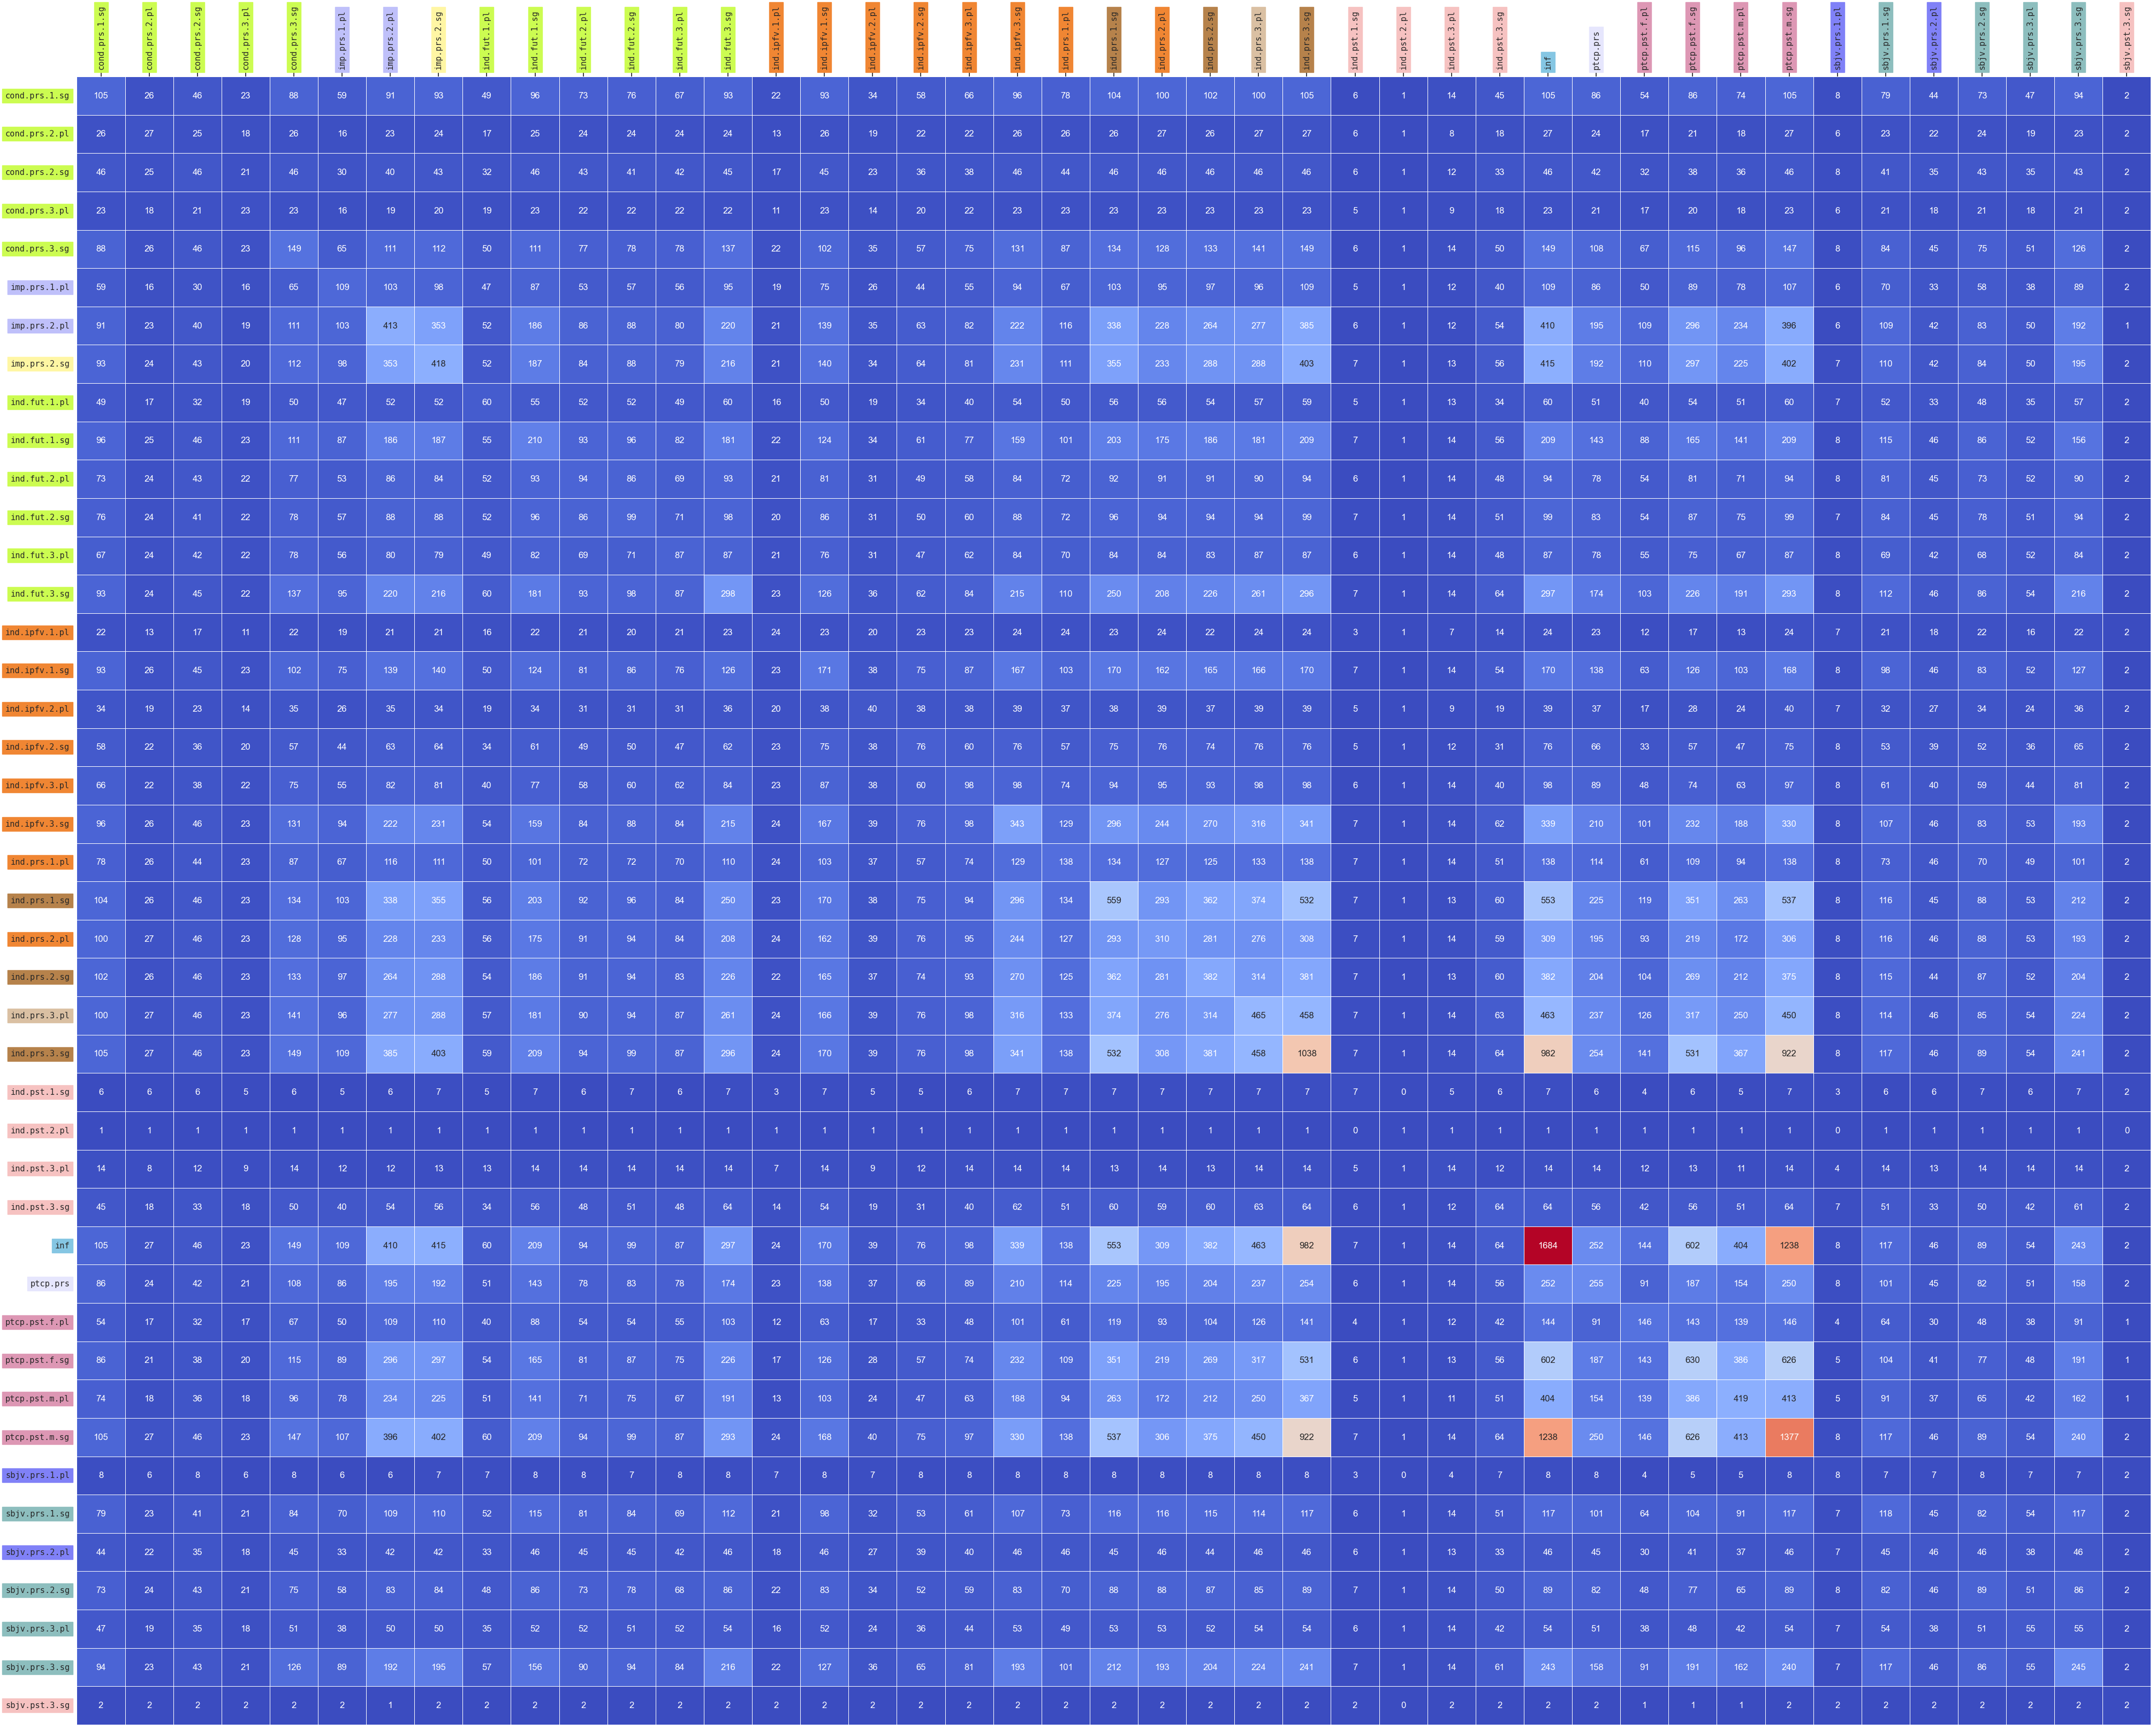

In [29]:
sns.set(rc={'figure.figsize':(50,40)})
ax=sns.heatmap(dfCoforms,annot=True,linewidth=.5,cmap="coolwarm",fmt="d",cbar=False)
ax.xaxis.tick_top()
ax.tick_params(axis='x', labelrotation=90)
ax.tick_params(axis='y', labelrotation=0)
colorerXTicks(ax,fSize=12)
colorerYTicks(ax,fSize=12)